In [1]:
%matplotlib inline

In [2]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

/Users/prafull/miniconda3/envs/gordian/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


Found 2 model directories: ['anthropic_claude-3.7-sonnet', 'google_gemini-2.0-flash']
Loading 100 game prompts from anthropic_claude-3.7-sonnet...
Loading 100 game prompts from google_gemini-2.0-flash...
Loaded 200 game prompts in total

Basic statistics:
Number of unique models: 2
Models: ['anthropic:claude-3.7-sonnet' 'google:gemini-2.0-flash']

Sample concepts:
Concept 1: Control a snowplow clearing increasingly complex road patterns while managing a limited supply of sa...
Concept 2: What if you were a single grain of salt? Navigate a shaker and avoid getting stuck. Season the meal ...
Concept 3: Imagine a game where you control a bouncing period at the end of a sentence. Avoid semicolons and co...
Concept 4: A game where you're a growing shadow that extends as the sun moves across the sky, using your changi...
Concept 5: A game where the player controls a single sugar crystal. Navigate a bowl of cereal and avoid getting...

Genre distribution:
genre
Adventure, Arcade        28
Puz

<Figure size 1000x600 with 0 Axes>

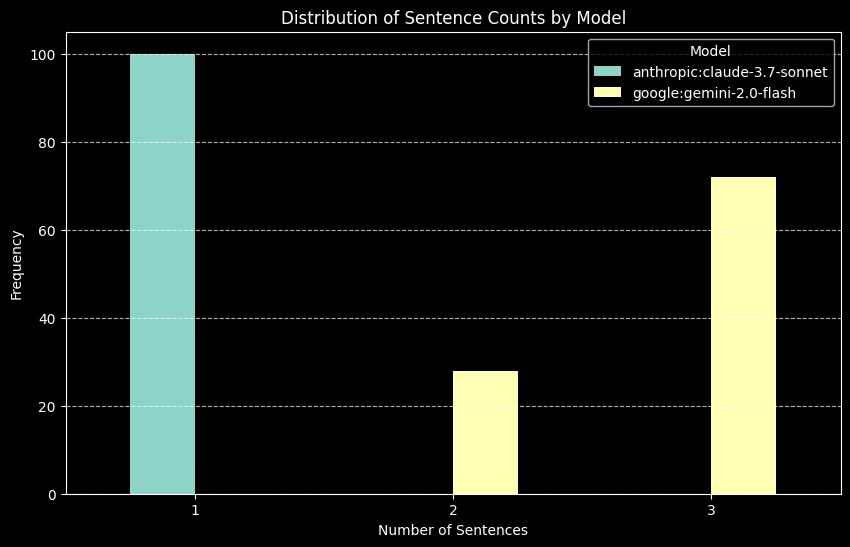

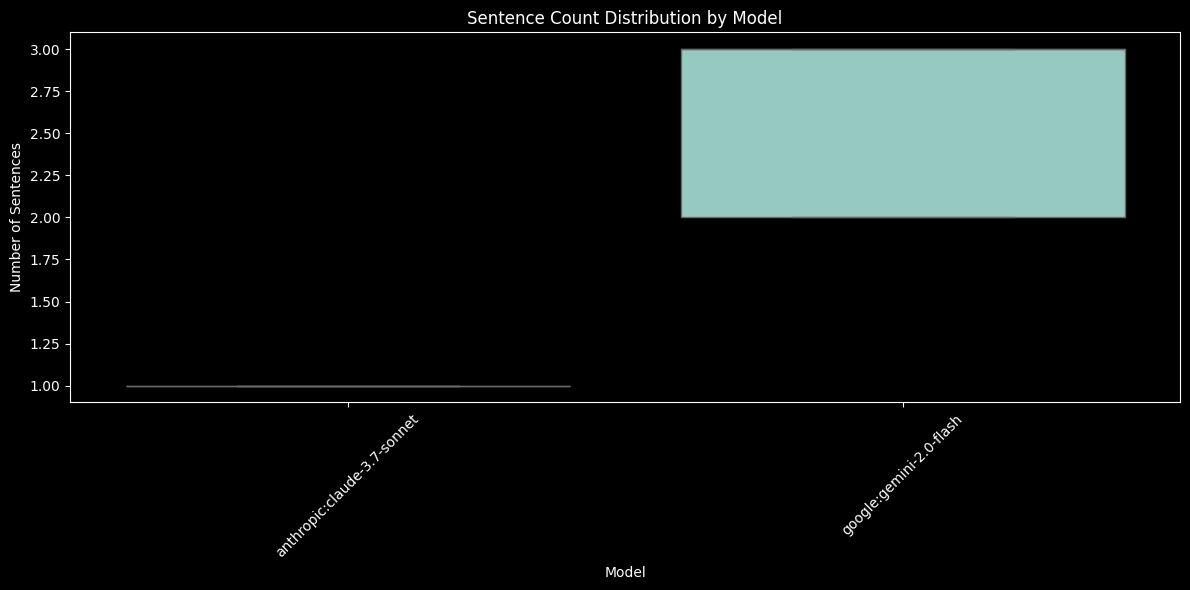

In [3]:
def load_game_prompts(base_dir="./new_games"):
    """
    Load all game prompts from the new_games_update directory for all models.
    
    Args:
        base_dir: Base directory containing model-specific subdirectories with game prompts
        
    Returns:
        DataFrame containing all game prompts with model information
    """
    all_games = []
    
    # Get all subdirectories (model names)
    model_dirs = [d for d in sorted(os.listdir(base_dir)) if os.path.isdir(os.path.join(base_dir, d))]
    
    print(f"Found {len(model_dirs)} model directories: {model_dirs}")
    
    for model_dir in model_dirs:
        model_path = os.path.join(base_dir, model_dir)
        game_files = [f for f in os.listdir(model_path) if f.endswith('.json')]
        
        print(f"Loading {len(game_files)} game prompts from {model_dir}...")
        
        for game_file in game_files:
            file_path = os.path.join(model_path, game_file)
            try:
                with open(file_path, 'r') as f:
                    game_data = json.load(f)
                    
                # Add model information if not already present
                if 'model' not in game_data:
                    game_data['model'] = model_dir.replace('_', ':')
                    
                all_games.append(game_data)
            except Exception as e:
                print(f"Error loading {file_path}: {str(e)}")
    
    # Convert to DataFrame
    df = pd.DataFrame(all_games)
    print(f"Loaded {len(df)} game prompts in total")
    
    return df

# Load all game prompts
game_prompts_df = load_game_prompts()

# Display basic statistics
if not game_prompts_df.empty:
    print("\nBasic statistics:")
    print(f"Number of unique models: {game_prompts_df['model'].nunique()}")
    print(f"Models: {game_prompts_df['model'].unique()}")
    
    # Display concept information
    if 'concept' in game_prompts_df.columns:
        print(f"\nSample concepts:")
        # Display a few sample concepts
        for i, concept in enumerate(game_prompts_df['concept'].sample(min(5, len(game_prompts_df))).values):
            print(f"Concept {i+1}: {concept[:100]}...")
    
    if 'genre' in game_prompts_df.columns:
        print(f"\nGenre distribution:")
        genre_counts = game_prompts_df['genre'].value_counts()
        print(genre_counts)
        
    # Analyze sentence length and distribution
    if 'concept' in game_prompts_df.columns:
        # Count sentences in each concept
        game_prompts_df['sentence_count'] = game_prompts_df['concept'].apply(
            lambda x: len([s for s in re.split(r'[.!?]+', x) if s.strip()])
        )
        
        # Calculate word count per concept
        game_prompts_df['word_count'] = game_prompts_df['concept'].apply(
            lambda x: len(x.split())
        )
        
        print("\nSentence statistics:")
        print(f"Average sentences per concept: {game_prompts_df['sentence_count'].mean():.2f}")
        print(f"Median sentences per concept: {game_prompts_df['sentence_count'].median()}")
        print(f"Min sentences: {game_prompts_df['sentence_count'].min()}")
        print(f"Max sentences: {game_prompts_df['sentence_count'].max()}")
        
        print("\nWord count statistics:")
        print(f"Average words per concept: {game_prompts_df['word_count'].mean():.2f}")
        print(f"Median words per concept: {game_prompts_df['word_count'].median()}")
        
        # Distribution of sentence counts
        print("\nSentence count distribution:")
        sentence_dist = game_prompts_df['sentence_count'].value_counts().sort_index()
        print(sentence_dist)
        
        # Plot sentence count distribution with integer x-axis
        plt.figure(figsize=(10, 6))
        # Get the range of sentence counts
        min_sentences = int(game_prompts_df['sentence_count'].min())
        max_sentences = int(game_prompts_df['sentence_count'].max())
        
        # Create a cross-tabulation of model and sentence count
        sentence_model_counts = pd.crosstab(game_prompts_df['sentence_count'], game_prompts_df['model'])
        
        # Plot stacked bar chart with integer x-axis
        sentence_model_counts.plot(kind='bar', stacked=False, figsize=(10, 6))
        plt.title('Distribution of Sentence Counts by Model')
        plt.xlabel('Number of Sentences')
        plt.ylabel('Frequency')
        plt.xticks(rotation=0)  # Keep x-axis labels horizontal
        plt.legend(title='Model')
        plt.grid(axis='y', linestyle='--', alpha=0.7)
        plt.show()
        
        # Compare sentence counts across models with boxplot
        if game_prompts_df['model'].nunique() > 1:
            plt.figure(figsize=(12, 6))
            sns.boxplot(x='model', y='sentence_count', data=game_prompts_df)
            plt.title('Sentence Count Distribution by Model')
            plt.xlabel('Model')
            plt.ylabel('Number of Sentences')
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
else:
    print("No game prompts found. Make sure the directory structure is correct.")


/Users/prafull/miniconda3/envs/gordian/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Embedding game concepts and visualizing in 2D space...
Using sentence-transformers model: all-MiniLM-L6-v2


Batches: 100%|██████████| 7/7 [00:00<00:00, 16.46it/s]
/Users/prafull/miniconda3/envs/gordian/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:780: FutureWarning: The default initialization in TSNE will change from 'random' to 'pca' in 1.2.
  warnings.warn(
/Users/prafull/miniconda3/envs/gordian/lib/python3.9/site-packages/sklearn/manifold/_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(



Calculating intra-class diversity for each model...

Intra-class Diversity Metrics (Cosine Distance):
--------------------------------------------------------------------------------
Model                          Count    Mean       Median     Min        Max        Std       
--------------------------------------------------------------------------------
anthropic:claude-3.7-sonnet    100      0.7425     0.7515     0.1353     1.0637     0.1169 (MOST DIVERSE)
google:gemini-2.0-flash        100      0.6707     0.6659     0.0527     1.0591     0.1621

Reducing dimensionality with t-SNE...


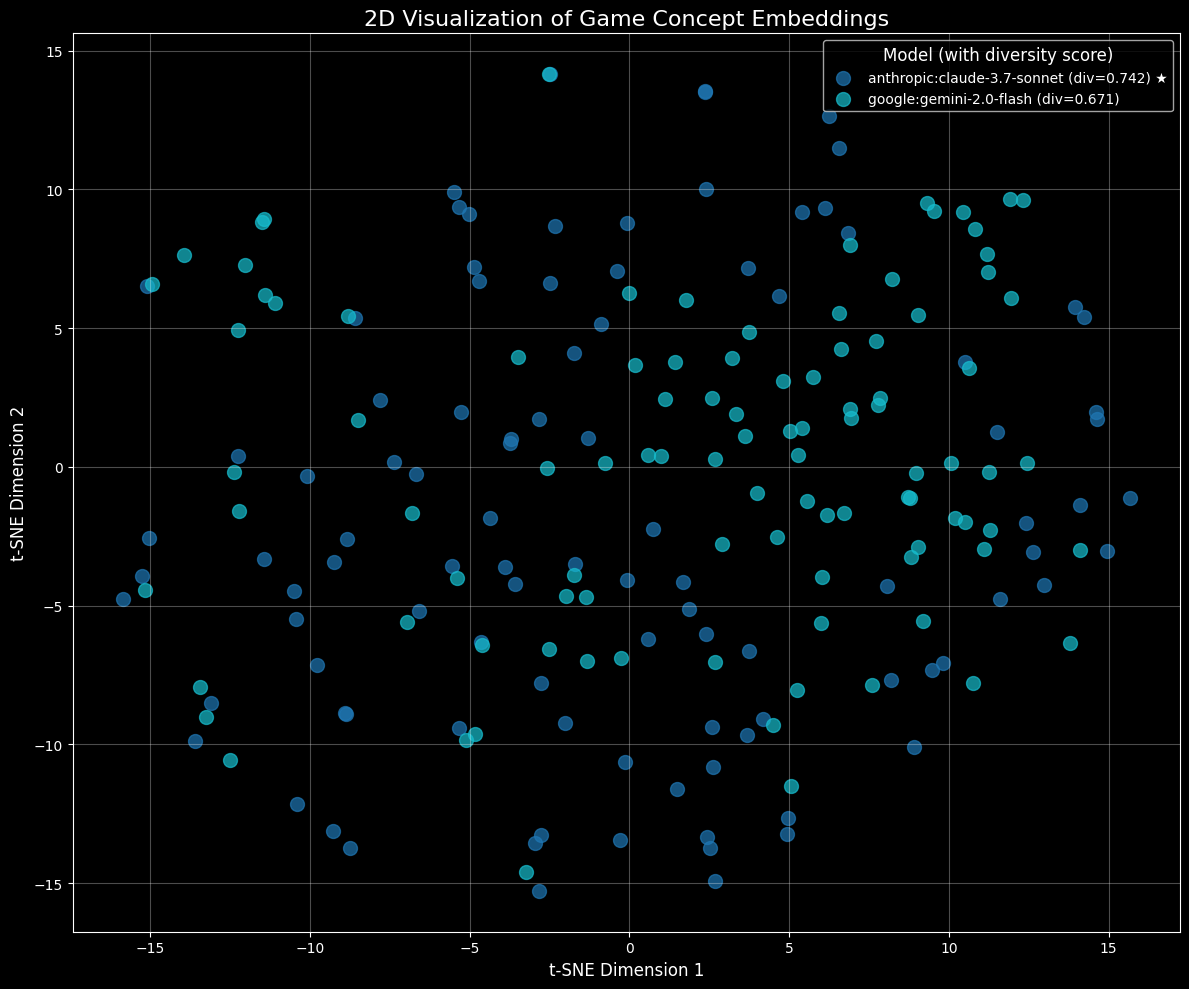


Most diverse model: anthropic:claude-3.7-sonnet with mean cosine distance of 0.7425

Example concepts (first 5):
1: Play as a juggler adding more balls to your routine, timing catches and throws while moving across a...
2: Play as a growing puddle of spilled coffee that spreads across an office, ruining paperwork while av...
3: A hot air balloon journey where players must manage altitude by collecting fuel for the burner while...
4: Control a growing chain of paperclips that can link to certain surfaces, creating paths across gaps ...
5: Control a sleepwalker who must be guided safely through a house full of hazards without waking them ...


In [4]:
# Embedding and visualizing game concepts
import numpy as np
from sklearn.manifold import TSNE
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.spatial.distance import pdist, squareform

if 'game_prompts_df' in locals() and not game_prompts_df.empty:
    print("\nEmbedding game concepts and visualizing in 2D space...")
    
    # Load a pre-trained sentence transformer model for embeddings
    try:
        model = SentenceTransformer('all-MiniLM-L6-v2')
        print("Using sentence-transformers model: all-MiniLM-L6-v2")
    except Exception as e:
        print(f"Error loading sentence-transformers model: {str(e)}")
        print("Installing sentence-transformers...")
        %pip install -q sentence-transformers
        model = SentenceTransformer('all-MiniLM-L6-v2')
    
    # Generate embeddings for each game concept
    concepts = game_prompts_df['concept'].tolist()
    embeddings = model.encode(concepts, show_progress_bar=True)
    
    # Calculate intra-class diversity for each model
    print("\nCalculating intra-class diversity for each model...")
    unique_models = game_prompts_df['model'].unique()
    diversity_metrics = {}
    
    for model_name in unique_models:
        # Get indices for this model
        model_indices = game_prompts_df[game_prompts_df['model'] == model_name].index
        
        if len(model_indices) > 1:  # Need at least 2 samples to calculate diversity
            # Get embeddings for this model
            model_embeddings = embeddings[model_indices]
            
            # Calculate pairwise distances
            pairwise_distances = pdist(model_embeddings, metric='cosine')
            
            # Calculate diversity metrics
            diversity_metrics[model_name] = {
                'mean_distance': np.mean(pairwise_distances),
                'median_distance': np.median(pairwise_distances),
                'min_distance': np.min(pairwise_distances),
                'max_distance': np.max(pairwise_distances),
                'std_distance': np.std(pairwise_distances),
                'sample_count': len(model_indices)
            }
        else:
            diversity_metrics[model_name] = {
                'mean_distance': 0,
                'median_distance': 0,
                'min_distance': 0,
                'max_distance': 0,
                'std_distance': 0,
                'sample_count': len(model_indices)
            }
    
    # Find the most diverse model
    most_diverse_model = max(diversity_metrics.items(), key=lambda x: x[1]['mean_distance'])
    
    # Print diversity metrics
    print("\nIntra-class Diversity Metrics (Cosine Distance):")
    print("-" * 80)
    print(f"{'Model':<30} {'Count':<8} {'Mean':<10} {'Median':<10} {'Min':<10} {'Max':<10} {'Std':<10}")
    print("-" * 80)
    for model_name, metrics in diversity_metrics.items():
        is_most_diverse = " (MOST DIVERSE)" if model_name == most_diverse_model[0] else ""
        print(f"{model_name:<30} {metrics['sample_count']:<8} {metrics['mean_distance']:.4f}     {metrics['median_distance']:.4f}     {metrics['min_distance']:.4f}     {metrics['max_distance']:.4f}     {metrics['std_distance']:.4f}{is_most_diverse}")
    
    # Reduce dimensionality to 2D using t-SNE
    print("\nReducing dimensionality with t-SNE...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(concepts)-1))
    embeddings_2d = tsne.fit_transform(embeddings)
    
    # Create a scatter plot with color coding by model
    plt.figure(figsize=(12, 10))
    
    # Get colors for each model
    colors = plt.cm.tab10(np.linspace(0, 1, len(unique_models)))
    
    # Plot each model with a different color
    for i, model_name in enumerate(unique_models):
        mask = game_prompts_df['model'] == model_name
        label_text = f"{model_name} (div={diversity_metrics[model_name]['mean_distance']:.3f})"
        if model_name == most_diverse_model[0]:
            label_text += " ★"  # Add star to most diverse model
        
        plt.scatter(
            embeddings_2d[mask, 0], 
            embeddings_2d[mask, 1],
            c=[colors[i]],
            label=label_text,
            alpha=0.7,
            s=100
        )
    
    # Add labels and legend
    plt.title('2D Visualization of Game Concept Embeddings', fontsize=16)
    plt.xlabel('t-SNE Dimension 1', fontsize=12)
    plt.ylabel('t-SNE Dimension 2', fontsize=12)
    plt.legend(title='Model (with diversity score)', title_fontsize=12, fontsize=10)
    plt.grid(alpha=0.3)
    
    # Add annotations for a few random points (optional)
    if len(concepts) <= 50:  # Only annotate if not too many points
        for i in range(len(concepts)):
            plt.annotate(
                f"{i+1}",  # Just show index number to avoid cluttering
                (embeddings_2d[i, 0], embeddings_2d[i, 1]),
                fontsize=8,
                alpha=0.7
            )
    
    plt.tight_layout()
    plt.show()
    
    # Print most diverse model summary
    print(f"\nMost diverse model: {most_diverse_model[0]} with mean cosine distance of {most_diverse_model[1]['mean_distance']:.4f}")
    
    # Optional: Print a few example concepts with their indices for reference
    print("\nExample concepts (first 5):")
    for i in range(min(5, len(concepts))):
        print(f"{i+1}: {concepts[i][:100]}...")
else:
    print("No game prompts data available for embedding visualization.")




In [6]:
# Display random samples from each model with color-coded backgrounds
import random
from IPython.display import display, HTML

def get_colored_html(text, color):
    """Create HTML with colored background for text and white text"""
    return f'<div style="background-color:{color}; color:white; padding:10px; margin:5px; border-radius:5px;">{text}</div>'

if 'game_prompts_df' in locals() and not game_prompts_df.empty:
    # Define darker background colors
    bg_colors = ['#990000', '#000099', '#006600', '#999900']  # dark red, blue, green, yellow
    
    # Get unique models
    unique_models = game_prompts_df['model'].unique()
    
    html_output = '<h2>Random Game Concepts by Model</h2>'
    
    # For each model, select 10 random concepts
    for i, model in enumerate(unique_models):
        model_data = game_prompts_df[game_prompts_df['model'] == model]
        
        # Get random sample (or all if less than 10)
        sample_size = min(50, len(model_data))
        random_samples = model_data.head(100)
        
        # Get color for this model (cycle through colors)
        color = bg_colors[i % len(bg_colors)]
        
        # Add model header
        html_output += f'<h3>{model}</h3>'
        
        # Add each concept with colored background and white text
        for j, (_, row) in enumerate(random_samples.iterrows()):
            concept = row['concept']
            # Truncate long concepts
            if len(concept) > 300:
                concept = concept[:300] + '...'
            
            html_output += get_colored_html(f"<b>{j+1}.</b> {concept}", color)
    
    # Display the HTML
    display(HTML(html_output))
else:
    print("No game prompts data available to display random concepts.")



Analyzing models: 2it [00:00, 21.16it/s]



Most Similar Game Concepts by Model:

anthropic:claude-3.7-sonnet
----------------------------------------

Pair 1 (Similarity: 0.865):
Concept 1: Guide a paper airplane through an office environment where desk fans create updrafts and open windows cause dangerous crosswinds.
Concept 2: Guide a paper airplane through an office building by creating air currents from spinning fans and opening or closing windows.

Pair 2 (Similarity: 0.826):
Concept 1: Control a growing snowball rolling downhill, absorbing snow to grow while avoiding rocks that chip away at your size.
Concept 2: Control a growing snowman rolling downhill, collecting more snow to grow bigger while avoiding warm objects that melt parts away.

Pair 3 (Similarity: 0.757):
Concept 1: Play as a magnet that can attract or repel metal objects to solve navigation challenges and defeat robotic enemies.
Concept 2: A game where you're a growing collection of magnets that attract useful metal objects but must avoid attracting too man

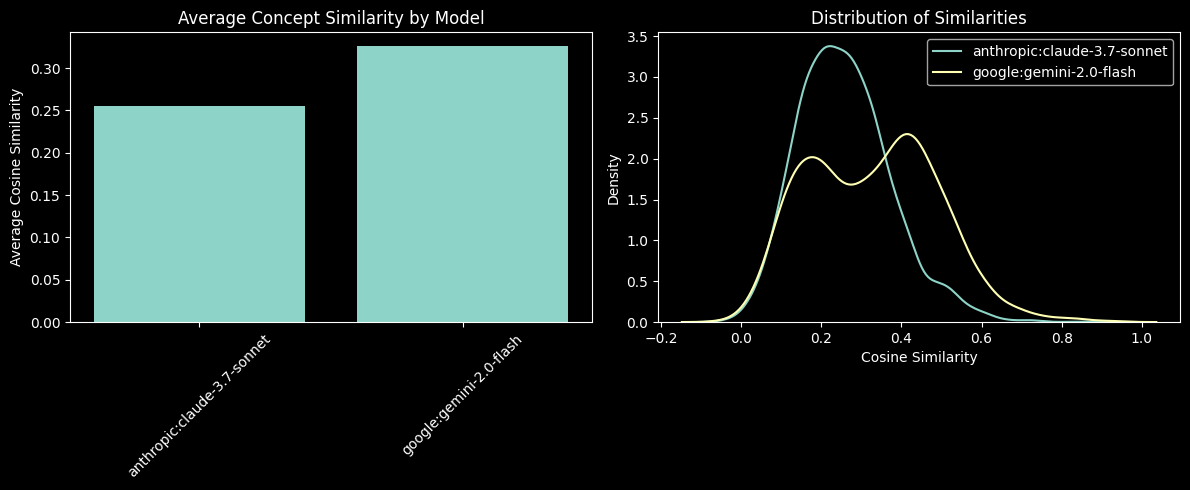

In [10]:
from sentence_transformers import SentenceTransformer
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import seaborn as sns

# Load a pre-trained sentence transformer model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Group concepts by model
grouped_concepts = game_prompts_df.groupby('model')['concept'].apply(list)

# Calculate embeddings and find most similar pairs for each model
embeddings_by_model = {}
similarities = {}
most_similar_pairs = {}

for model_name, concepts in tqdm(grouped_concepts.items(), desc="Analyzing models"):
    # Get embeddings for all concepts in this model
    embeddings = model.encode(concepts)
    embeddings_by_model[model_name] = embeddings
    
    # Calculate pairwise cosine similarities
    sim_matrix = cosine_similarity(embeddings)
    np.fill_diagonal(sim_matrix, 0)  # Zero out self-similarities
    
    # Get average similarity
    avg_similarity = sim_matrix.mean()
    similarities[model_name] = avg_similarity
    
    # Find the most similar pairs
    n_pairs = 3  # Number of most similar pairs to show
    most_similar = []
    
    # Get indices of top N highest similarities
    sim_matrix_flat = sim_matrix.flatten()
    top_indices = np.argsort(sim_matrix_flat)[-n_pairs*2:][::-2]  # Skip every other (duplicates)
    
    for idx in top_indices:
        i, j = idx // len(sim_matrix), idx % len(sim_matrix)
        similarity = sim_matrix[i, j]
        most_similar.append({
            'concept1': concepts[i],
            'concept2': concepts[j],
            'similarity': similarity
        })
    
    most_similar_pairs[model_name] = most_similar

# Print most similar pairs for each model
print("\nMost Similar Game Concepts by Model:")
print("=" * 80)
for model_name, pairs in most_similar_pairs.items():
    print(f"\n{model_name}")
    print("-" * 40)
    for i, pair in enumerate(pairs, 1):
        print(f"\nPair {i} (Similarity: {pair['similarity']:.3f}):")
        print(f"Concept 1: {pair['concept1']}")
        print(f"Concept 2: {pair['concept2']}")

# Visualization
plt.figure(figsize=(12, 5))

# Bar plot of average similarities
plt.subplot(1, 2, 1)
plt.bar(similarities.keys(), similarities.values())
plt.title('Average Concept Similarity by Model')
plt.xticks(rotation=45)
plt.ylabel('Average Cosine Similarity')

# Distribution plot
plt.subplot(1, 2, 2)
for model_name, embeddings in embeddings_by_model.items():
    sim_matrix = cosine_similarity(embeddings)
    np.fill_diagonal(sim_matrix, 0)
    similarities_flat = sim_matrix[np.triu_indices(len(sim_matrix), k=1)]
    sns.kdeplot(similarities_flat, label=model_name)
plt.title('Distribution of Similarities')
plt.xlabel('Cosine Similarity')
plt.legend()

plt.tight_layout()
plt.show()



In [32]:
game_prompts_df

,concept,genre,model,sentence_count,word_count
0,A survival game where your character must osci...,Survival,anthropic:claude-3.7-sonnet,1,19
1,Control a character who can manipulate their o...,Adventure,anthropic:claude-3.7-sonnet,1,19
2,You control a character who can only jump when...,Platformer,anthropic:claude-3.7-sonnet,1,17
3,Control a character who continuously swaps bet...,Platformer,anthropic:claude-3.7-sonnet,1,17
4,Navigate as a character who can stretch like r...,Platformer,anthropic:claude-3.7-sonnet,1,19
...,...,...,...,...,...
395,You're a solar-powered robot that slows in sha...,"Adventure, Survival",anthropic:claude-3.7-sonnet,2,29
396,Control a growing tree whose branches extend i...,"Adventure, Puzzle",anthropic:claude-3.7-sonnet,2,32
397,A game where you're a bubble rising through in...,"Arcade, Platformer",anthropic:claude-3.7-sonnet,2,31
398,Control a sand castle gradually eroding in ris...,"Survival, Adventure",anthropic:claude-3.7-sonnet,2,28


In [20]:
game_prompts_df['concept'].iloc[90]

"You're a chameleon whose color changes with each movement. Match your color to your background to become invisible to predators, but this camouflage makes it harder for you to see yourself too."

In [21]:
game_prompts_df['concept'].iloc[79]

"You're a chameleon whose color changes with each movement. Match your color to your background to become invisible to predators, creating a unique stealth experience where camouflage is your only defense."